In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f101459f72180956da498610009fb21e5c242b51e4057b9da8a80f8b2ffe1f92
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
import matplotlib.pyplot as mpl

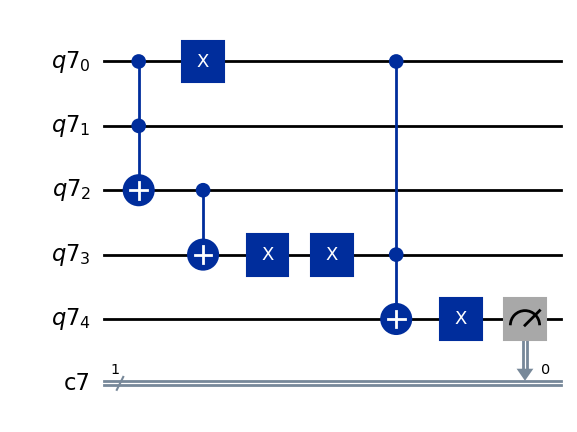

In [ ]:
#Implementation of Deutsch's algorithm
# (A ANDN B) => A
# NOT (A AND B) OR A (this is easier to deal with)
# THIS IS NOT AN ORACLE FOR DEUTSCH'S ALGORITHM
# (IT'S A REVERSABLE QUANTUM CIRCUIT THAT EVALUATES A BOOLEAN EXPRESSION)
q = QuantumRegister(5)
c = ClassicalRegister(1)
qc = QuantumCircuit(q,c)



# q[0] = A
# q[1] = B
# q[2] = A AND B
# q[3] = NOT(A AND B)
# q[4] = output
#there are a lot of variables to deal with so label each

# compute A AND B ()
# two controls since A AND B are determined by two existing qubits A and B
qc.ccx(q[0], q[1], q[2])

# copy the value in q2 (A AND B) into q3
qc.cx(q[2], q[3])
# negate q3 to get the value of NOT (A AND B)
qc.x(q[3])

# X OR Y = NOT((NOT X) AND (NOT Y))
#let:
# X = q3 = NOT (A AND B)
# Y = q0 = A
qc.x(q[3]) # negates NOT (A AND B)
qc.x(q[0]) # negates A

#apply the AND operator to X & Y
qc.ccx(q[3], q[0], q[4])

#negate it to actually apply De'Morgans laws
qc.x(q[4])

qc.measure(q[4], c[0])

qc.draw('mpl')